# Data Preprocessing 

The `TimeSeriesData` class provides a standard container for photometric time series with built-in preprocessing, PSD, and ACF computation. 

```{admonition} Sections

1. Creating a `TimeSeriesData` from simulated data
2. Loading Kepler data via `lightkurve`
3. Normalization, sigma clipping, PSD, and ACF
```

In [9]:
import sys
sys.path.append("../..")

import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({                                                                                  
    "font.size":        16,   # base font size                                                         
    "axes.titlesize":   20,   # axes title                                                             
    "axes.labelsize":   18,   # x/y axis labels                                                        
    "xtick.labelsize":  14,   # x tick labels                                                          
    "ytick.labelsize":  14,   # y tick labels                                                          
    "legend.fontsize":  14,                                                                            
    "figure.titlesize": 22,   # suptitle
    "axes.formatter.useoffset": False,  # disable scientific notation offset                                                   
})  

from spotgp import TimeSeriesData

---
## 1. Simulated data

Create a synthetic lightcurve with a periodic signal, noise, and a few outliers.

In [12]:
np.random.seed(42)

N = 500
t = np.sort(np.random.uniform(0, 100, N))  # irregular sampling
period = 8.0
flux = 1.0 + 0.005 * np.sin(2 * np.pi * t / period) + 0.001 * np.random.randn(N)
flux_err = np.full(N, 0.001)

# Inject some outliers and NaNs
flux[10] = 1.05
flux[200] = 0.95
flux[300] = np.nan

ts = TimeSeriesData(t, flux, flux_err)
print(ts)
print(f"Median flux: {np.median(ts.y):.6f}")

TimeSeriesData(N=499, baseline=98.79, median_dt=0.1299)
Median flux: 1.000000


The constructor automatically:
- Removed the NaN entry (N went from 500 to 499)
- Normalized the flux so the median is 1.0

### Plot the raw time series

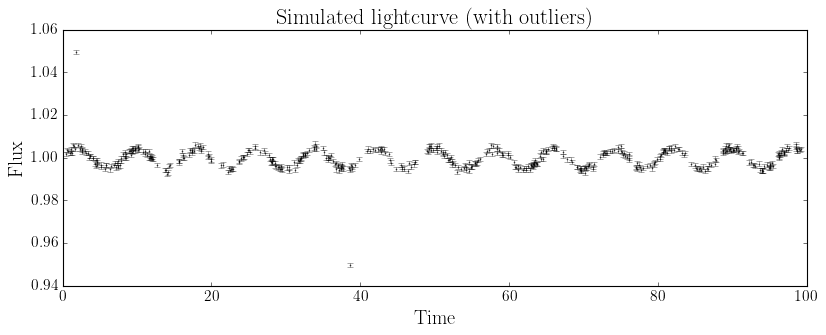

In [13]:
ts.plot()
plt.title("Simulated lightcurve (with outliers)")
plt.show()

### Sigma clipping

Remove the outliers with `sigma_clip()`:

Before clipping: N = 497
After clipping:  N = 497


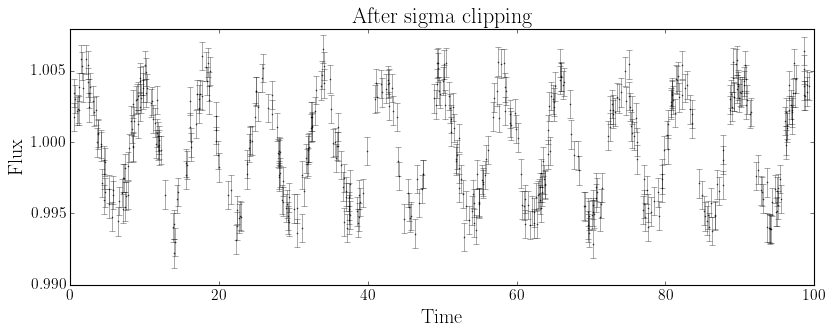

In [11]:
print(f"Before clipping: N = {ts.N}")
ts.sigma_clip(lower=3, upper=3)
print(f"After clipping:  N = {ts.N}")

ts.plot()
plt.title("After sigma clipping")
plt.show()

### PSD and ACF

Compute and plot the power spectral density and autocorrelation function:

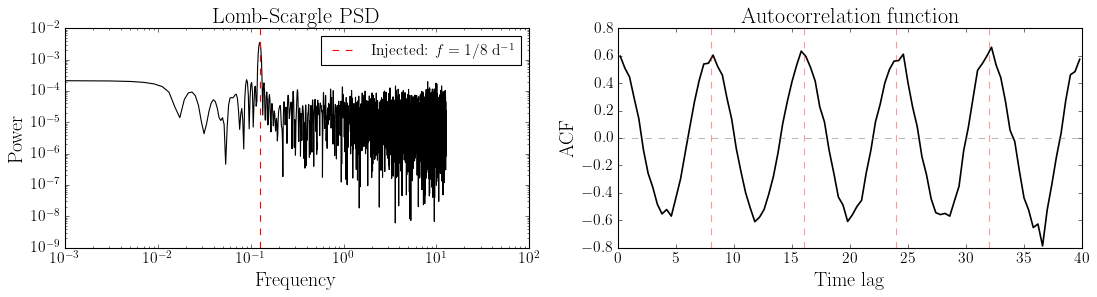

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ts.plot_psd(ax=axes[0])
axes[0].axvline(1.0 / period, color="r", ls="--", label=f"Injected: $f = 1/{period:.0f}$ d$^{{-1}}$")
axes[0].legend()
axes[0].set_title("Lomb-Scargle PSD")

ts.plot_acf(ax=axes[1], n_bins=100, max_lag=40)
for i in range(1, 5):
    axes[1].axvline(i * period, color="r", ls="--", alpha=0.4)
axes[1].set_title("Autocorrelation function")

plt.tight_layout()
plt.show()

The PSD peaks at the injected frequency ($1/8$ d$^{-1}$) and the ACF shows periodicity at multiples of 8 days.

---
## 2. Kepler data with `lightkurve`

Load a Kepler quarter for a known active star and preprocess it with `TimeSeriesData`.

:::{note}
This section requires `lightkurve`. Install it with `pip install lightkurve`.
:::

In [16]:
import lightkurve as lk

# Download a single Kepler quarter for a spotted star
search = lk.search_lightcurve("KIC 7985370", mission="Kepler", cadence="long", quarter=5)
lc = search.download()
lc.head()

time,flux,flux_err,quality,timecorr,centroid_col,centroid_row,cadenceno,sap_flux,sap_flux_err,sap_bkg,sap_bkg_err,pdcsap_flux,pdcsap_flux_err,sap_quality,psf_centr1,psf_centr1_err,psf_centr2,psf_centr2_err,mom_centr1,mom_centr1_err,mom_centr2,mom_centr2_err,pos_corr1,pos_corr2
,electron / s,electron / s,,d,pix,pix,,electron / s,electron / s,electron / s,electron / s,electron / s,electron / s,,pix,pix,pix,pix,pix,pix,pix,pix,pix,pix
Time,float32,float32,int32,float32,float64,float64,int32,float32,float32,float32,float32,float32,float32,int32,float64,float32,float64,float32,float64,float32,float64,float32,float32,float32
443.48970645623194,———,———,10000,-1.448464e-03,319.40248,398.02002,16373,1.5593305e+06,3.1996595e+01,8.0061802e+03,1.6346836e+00,———,———,10000,———,———,———,———,319.40248,2.0221185e-05,398.02002,2.9403081e-05,-4.5754738e-02,4.8700325e-02
443.51014069512166,1.5641606e+06,3.2047684e+01,10000000010000,-1.447925e-03,319.40256,398.02001,16374,1.5606115e+06,3.2009605e+01,8.0055918e+03,1.6347697e+00,1.5641606e+06,3.2047684e+01,10000000010000,———,———,———,———,319.40256,2.0208812e-05,398.02001,2.9394563e-05,-4.5619853e-02,4.9024601e-02
443.5305747343591,1.5655112e+06,3.2063877e+01,10000000010000,-1.447386e-03,319.40289,398.01947,16375,1.5619460e+06,3.2023129e+01,8.0033838e+03,1.6351467e+00,1.5655112e+06,3.2063877e+01,10000000010000,———,———,———,———,319.40289,2.0198473e-05,398.01947,2.9383289e-05,-4.5340929e-02,4.8469041e-02
443.55100887370645,1.5667932e+06,3.2078529e+01,10000,-1.446846e-03,319.40306,398.01928,16376,1.5632136e+06,3.2036301e+01,8.0128496e+03,1.6329130e+00,1.5667932e+06,3.2078529e+01,10000,———,———,———,———,319.40306,2.0186624e-05,398.01928,2.9375227e-05,-4.5147281e-02,4.8476472e-02
443.5714431134111,1.5680732e+06,3.2089455e+01,10010000,-1.446307e-03,319.40302,398.01933,16377,1.5645386e+06,3.2048767e+01,8.0063745e+03,1.6347470e+00,1.5680732e+06,3.2089455e+01,10010000,———,———,———,———,319.40302,2.0174755e-05,398.01933,2.9367231e-05,-4.5176014e-02,4.8612297e-02


In [ ]:
ts_kepler = TimeSeriesData.from_lightkurve(lc, normalize=True)
print(ts_kepler)

TimeSeriesData(N=4486, baseline=94.65, median_dt=0.0204)


### Plot the raw lightcurve

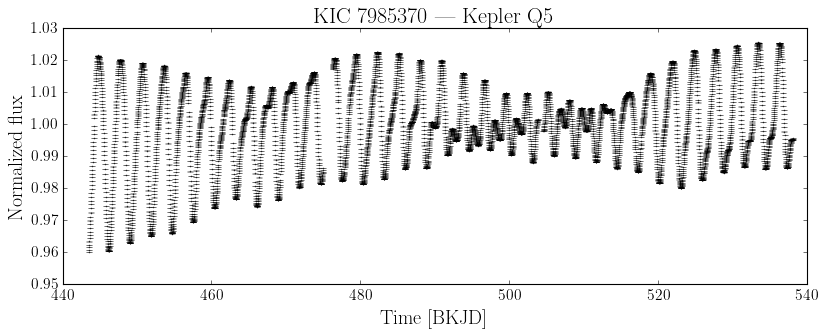

In [18]:
ts_kepler.plot(xlabel="Time [BKJD]", ylabel="Normalized flux")
plt.title("KIC 7985370 — Kepler Q5")
plt.show()

### Sigma clip and re-plot

Before clipping: N = 4486
After clipping:  N = 4478


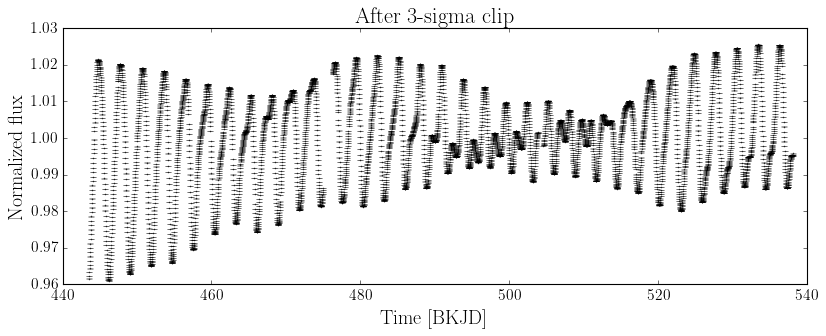

In [19]:
print(f"Before clipping: N = {ts_kepler.N}")
ts_kepler.sigma_clip(lower=3, upper=3)
print(f"After clipping:  N = {ts_kepler.N}")

ts_kepler.plot(xlabel="Time [BKJD]", ylabel="Normalized flux")
plt.title("After 3-sigma clip")
plt.show()

### PSD and ACF

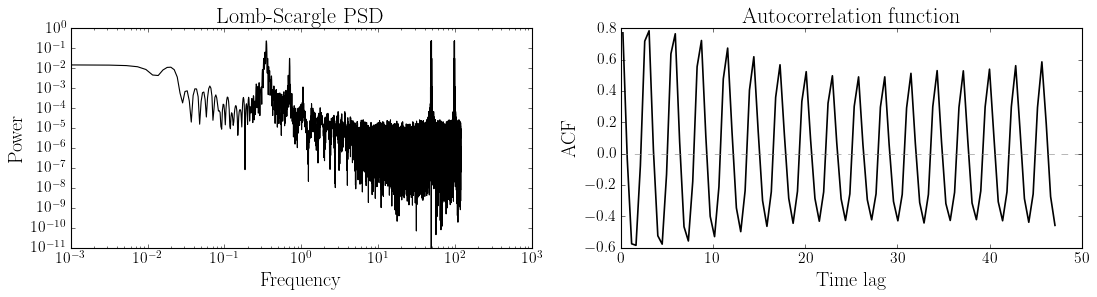

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ts_kepler.plot_psd(ax=axes[0])
axes[0].set_title("Lomb-Scargle PSD")

ts_kepler.plot_acf(ax=axes[1], n_bins=100)
axes[1].set_title("Autocorrelation function")

plt.tight_layout()
plt.show()

### Summary panel

A combined three-panel view of the data:

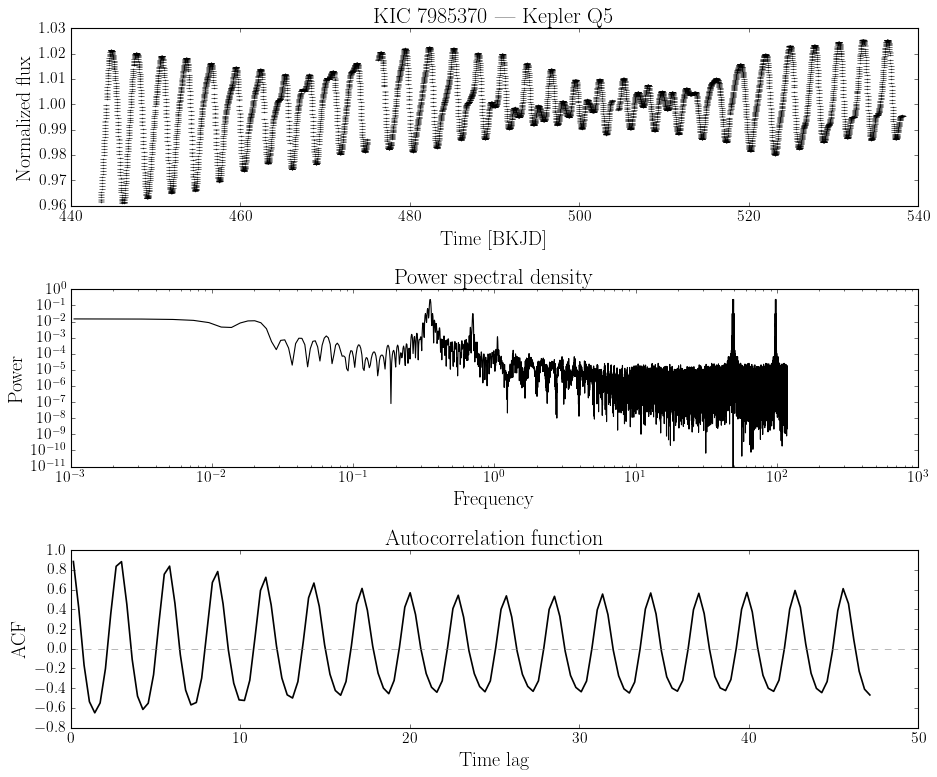

In [21]:
fig, axes = plt.subplots(3, 1, figsize=(12, 10))

ts_kepler.plot(ax=axes[0], xlabel="Time [BKJD]", ylabel="Normalized flux")
axes[0].set_title("KIC 7985370 — Kepler Q5")

ts_kepler.plot_psd(ax=axes[1])
axes[1].set_title("Power spectral density")

ts_kepler.plot_acf(ax=axes[2], n_bins=150)
axes[2].set_title("Autocorrelation function")

plt.tight_layout()
plt.show()

---
## API summary

| Method | Description |
|---|---|
| `TimeSeriesData(x, y, yerr)` | Create from arrays (auto-removes NaN, normalizes by default) |
| `TimeSeriesData.from_lightkurve(lc)` | Create from a `lightkurve.LightCurve` |
| `.normalize()` | Divide flux by median |
| `.sigma_clip(lower, upper)` | Remove outliers beyond N-sigma |
| `.compute_psd()` | Lomb-Scargle PSD |
| `.compute_acf()` | Binned empirical ACF |
| `.plot()` | Plot time series with error bars |
| `.plot_psd()` | Plot PSD (log-log by default) |
| `.plot_acf()` | Plot ACF |